# Two-View Token Count Analysis

**Question**: Both views apply contiguous mask + random drop independently from the same distribution.
Do they end up with similar valid-token counts? How different are they really?

In [1]:
import sys, os

os.chdir(os.path.join(os.path.dirname(os.path.abspath(".")), ""))
sys.path.insert(0, os.path.abspath(".."))
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import tensorflow as tf

from input_pipeline import (
    TfLightningDataModule,
    _build_dataset,
    _NUM_PEAKS_OUTPUT,
    _augment_sigreg_batch_tf,
    _batched_parse_and_transform,
)
from configs.gems_a_50_mask import get_config

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "figure.facecolor": "white",
        "axes.facecolor": "#f8f8f8",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)

cfg = get_config()
dm = TfLightningDataModule(cfg, seed=42)
print(f"Config masking params:")
print(
    f"  contiguous_mask_fraction: [{cfg.sigreg_contiguous_mask_fraction_min}, {cfg.sigreg_contiguous_mask_fraction_max}]"
)
print(
    f"  random_drop_fraction: [{cfg.sigreg_random_drop_fraction_min}, {cfg.sigreg_random_drop_fraction_max}]"
)
print(f"  mz_jitter_std: {cfg.sigreg_mz_jitter_std}")
print(f"  intensity_jitter_std: {cfg.sigreg_intensity_jitter_std}")

Config masking params:
  contiguous_mask_fraction: [0.1, 0.4]
  random_drop_fraction: [0.05, 0.15]
  mz_jitter_std: 0.0001
  intensity_jitter_std: 0.001


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Collect Statistics Over Many Batches

For each batch, record:
- Original valid count (pre-augmentation)
- View1 encoder-visible count (`fused_valid_mask[:B]`)
- View2 encoder-visible count (`fused_valid_mask[B:]`)
- View1 masked count (`fused_masked_positions[:B]`)
- View2 masked count (`fused_masked_positions[B:]`)
- Derived original-valid for both views (`valid | masked`)

In [2]:
aug_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=512,
    shuffle_buffer=100_000,
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    include_sigreg_augmentation=True,
    sigreg_contiguous_mask_fraction_min=cfg.sigreg_contiguous_mask_fraction_min,
    sigreg_contiguous_mask_fraction_max=cfg.sigreg_contiguous_mask_fraction_max,
    sigreg_random_drop_fraction_min=cfg.sigreg_random_drop_fraction_min,
    sigreg_random_drop_fraction_max=cfg.sigreg_random_drop_fraction_max,
    sigreg_mz_jitter_std=cfg.sigreg_mz_jitter_std,
    sigreg_intensity_jitter_std=cfg.sigreg_intensity_jitter_std,
    peak_ordering=cfg.peak_ordering,
)

N_BATCHES = 200
B = 512

orig_valid_counts = []  # original valid peaks per sample
v1_visible_counts = []  # view1 encoder-visible
v2_visible_counts = []  # view2 encoder-visible
v1_masked_counts = []  # view1 masked positions
v2_masked_counts = []  # view2 masked positions
v1_orig_valid_counts = []  # view1 original-valid (visible + masked)
v2_orig_valid_counts = []  # view2 original-valid (visible + masked)

it = iter(aug_ds.as_numpy_iterator())
for i in range(N_BATCHES):
    batch = next(it)

    orig_valid_counts.append(batch["peak_valid_mask"].sum(axis=1))  # [B]

    fv = batch["fused_valid_mask"]  # [2B, N]
    fm = batch["fused_masked_positions"]  # [2B, N]

    v1_vis = fv[:B].sum(axis=1)
    v2_vis = fv[B:].sum(axis=1)
    v1_mask = fm[:B].sum(axis=1)
    v2_mask = fm[B:].sum(axis=1)
    v1_orig = (fv[:B] | fm[:B]).sum(axis=1)
    v2_orig = (fv[B:] | fm[B:]).sum(axis=1)

    v1_visible_counts.append(v1_vis)
    v2_visible_counts.append(v2_vis)
    v1_masked_counts.append(v1_mask)
    v2_masked_counts.append(v2_mask)
    v1_orig_valid_counts.append(v1_orig)
    v2_orig_valid_counts.append(v2_orig)

    if (i + 1) % 50 == 0:
        print(f"  Collected {i + 1}/{N_BATCHES} batches ({(i + 1) * B:,} samples)")

orig_valid_counts = np.concatenate(orig_valid_counts)
v1_visible_counts = np.concatenate(v1_visible_counts)
v2_visible_counts = np.concatenate(v2_visible_counts)
v1_masked_counts = np.concatenate(v1_masked_counts)
v2_masked_counts = np.concatenate(v2_masked_counts)
v1_orig_valid_counts = np.concatenate(v1_orig_valid_counts)
v2_orig_valid_counts = np.concatenate(v2_orig_valid_counts)

n_samples = len(orig_valid_counts)
print(f"\nTotal samples: {n_samples:,}")
print(
    f"\nOriginal valid peaks: mean={orig_valid_counts.mean():.1f}, std={orig_valid_counts.std():.1f}"
)
print(
    f"View1 encoder-visible: mean={v1_visible_counts.mean():.1f}, std={v1_visible_counts.std():.1f}"
)
print(
    f"View2 encoder-visible: mean={v2_visible_counts.mean():.1f}, std={v2_visible_counts.std():.1f}"
)
print(
    f"View1 masked:          mean={v1_masked_counts.mean():.1f}, std={v1_masked_counts.std():.1f}"
)
print(
    f"View2 masked:          mean={v2_masked_counts.mean():.1f}, std={v2_masked_counts.std():.1f}"
)
print(
    f"View1 orig-valid:      mean={v1_orig_valid_counts.mean():.1f}, std={v1_orig_valid_counts.std():.1f}"
)
print(
    f"View2 orig-valid:      mean={v2_orig_valid_counts.mean():.1f}, std={v2_orig_valid_counts.std():.1f}"
)

  Collected 50/200 batches (25,600 samples)
  Collected 100/200 batches (51,200 samples)


  Collected 150/200 batches (76,800 samples)
  Collected 200/200 batches (102,400 samples)

Total samples: 102,400

Original valid peaks: mean=40.8, std=17.5
View1 encoder-visible: mean=28.5, std=12.3
View2 encoder-visible: mean=28.5, std=12.3
View1 masked:          mean=12.3, std=6.7
View2 masked:          mean=12.3, std=6.7
View1 orig-valid:      mean=40.8, std=17.5
View2 orig-valid:      mean=40.8, std=17.5


## 2. View1 vs View2 Encoder-Visible Token Counts

Scatter plot showing correlation between the two views' visible token counts.
If they're similar, points cluster near the diagonal.

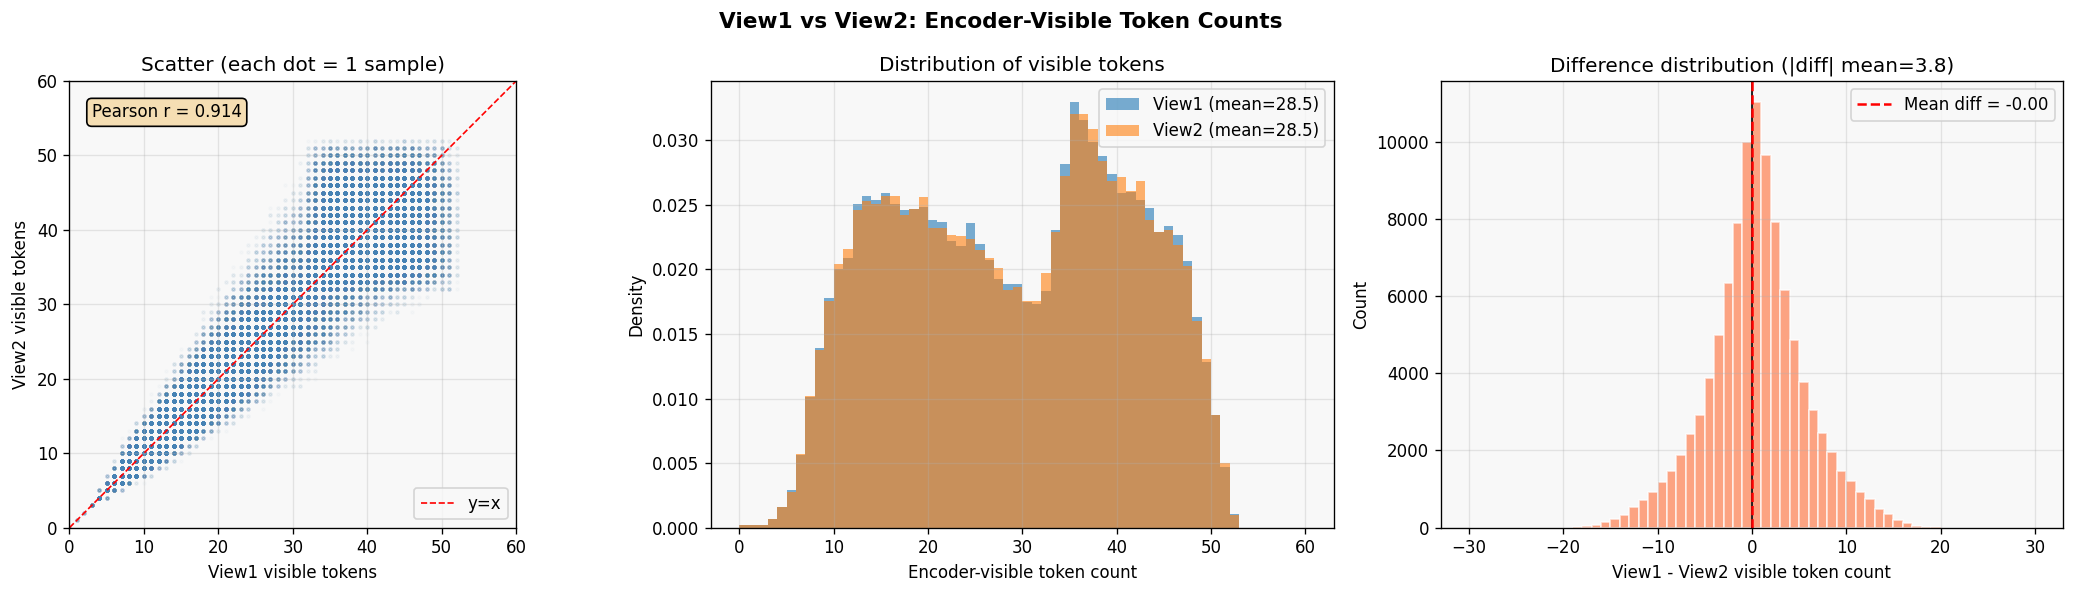


Mean |view1 - view2| visible: 3.83
Std  |view1 - view2| visible: 3.40
Fraction where |diff| <= 3: 0.576
Fraction where |diff| <= 5: 0.747


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "View1 vs View2: Encoder-Visible Token Counts", fontsize=13, fontweight="bold"
)

# (a) Scatter: view1 vs view2 visible counts
ax = axes[0]
ax.scatter(v1_visible_counts, v2_visible_counts, alpha=0.02, s=3, c="steelblue")
mn, mx = 0, 60
ax.plot([mn, mx], [mn, mx], "r--", lw=1, label="y=x")
ax.set_xlabel("View1 visible tokens")
ax.set_ylabel("View2 visible tokens")
ax.set_title("Scatter (each dot = 1 sample)")
corr = np.corrcoef(v1_visible_counts, v2_visible_counts)[0, 1]
ax.text(
    0.05,
    0.95,
    f"Pearson r = {corr:.3f}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat"),
)
ax.legend()
ax.set_xlim(mn, mx)
ax.set_ylim(mn, mx)
ax.set_aspect("equal")

# (b) Overlaid histograms
ax = axes[1]
bins = np.arange(0, 61)
ax.hist(
    v1_visible_counts,
    bins=bins,
    alpha=0.6,
    color="C0",
    label=f"View1 (mean={v1_visible_counts.mean():.1f})",
    density=True,
)
ax.hist(
    v2_visible_counts,
    bins=bins,
    alpha=0.6,
    color="C1",
    label=f"View2 (mean={v2_visible_counts.mean():.1f})",
    density=True,
)
ax.set_xlabel("Encoder-visible token count")
ax.set_ylabel("Density")
ax.set_title("Distribution of visible tokens")
ax.legend()

# (c) Histogram of |view1 - view2| difference
ax = axes[2]
diff = v1_visible_counts.astype(int) - v2_visible_counts.astype(int)
abs_diff = np.abs(diff)
ax.hist(diff, bins=np.arange(-30, 31), alpha=0.7, color="coral", edgecolor="white")
ax.axvline(0, color="black", ls="-", lw=1)
ax.axvline(
    diff.mean(), color="red", ls="--", lw=1.5, label=f"Mean diff = {diff.mean():.2f}"
)
ax.set_xlabel("View1 - View2 visible token count")
ax.set_ylabel("Count")
ax.set_title(f"Difference distribution (|diff| mean={abs_diff.mean():.1f})")
ax.legend()

plt.tight_layout()
plt.savefig("notebooks/fig_view_visible_comparison.png", bbox_inches="tight")
plt.show()

print(f"\nMean |view1 - view2| visible: {abs_diff.mean():.2f}")
print(f"Std  |view1 - view2| visible: {abs_diff.std():.2f}")
print(f"Fraction where |diff| <= 3: {(abs_diff <= 3).mean():.3f}")
print(f"Fraction where |diff| <= 5: {(abs_diff <= 5).mean():.3f}")

## 3. Why Are They Similar? — Theoretical Analysis

Both views independently sample:
- `contiguous_mask_fraction ~ U[0.10, 0.40]` → mean 0.25
- `random_drop_fraction ~ U[0.05, 0.15]` of survivors → mean 0.10

Expected surviving fraction = `(1 - mask_frac) * (1 - drop_frac)`

Since both views sample from the **same distribution** independently,
`E[view1_visible] = E[view2_visible]`. The only difference comes from random variance.

In [4]:
# Theoretical analysis
mask_min, mask_max = (
    cfg.sigreg_contiguous_mask_fraction_min,
    cfg.sigreg_contiguous_mask_fraction_max,
)
drop_min, drop_max = (
    cfg.sigreg_random_drop_fraction_min,
    cfg.sigreg_random_drop_fraction_max,
)

print("=== Theoretical Expectations ===")
print(f"Contiguous mask fraction: U[{mask_min}, {mask_max}]")
print(f"  E[mask_frac] = {(mask_min + mask_max) / 2:.3f}")
print(f"  Var[mask_frac] = {(mask_max - mask_min) ** 2 / 12:.6f}")
print(f"Random drop fraction: U[{drop_min}, {drop_max}]")
print(f"  E[drop_frac] = {(drop_min + drop_max) / 2:.3f}")
print(f"  Var[drop_frac] = {(drop_max - drop_min) ** 2 / 12:.6f}")

E_mask = (mask_min + mask_max) / 2
E_drop = (drop_min + drop_max) / 2
E_survive = (1 - E_mask) * (1 - E_drop)
print(
    f"\nE[surviving_fraction] = (1-{E_mask:.2f}) * (1-{E_drop:.2f}) = {E_survive:.4f}"
)
print(
    f"For avg {orig_valid_counts.mean():.0f} valid peaks: E[visible] = {orig_valid_counts.mean() * E_survive:.1f}"
)
print(
    f"Observed: View1={v1_visible_counts.mean():.1f}, View2={v2_visible_counts.mean():.1f}"
)

# Monte Carlo simulation of the difference
np.random.seed(0)
N_SIM = 1_000_000
n_valid_sim = np.random.choice(
    orig_valid_counts, size=N_SIM
)  # sample from observed distribution

# View 1
mf1 = np.random.uniform(mask_min, mask_max, N_SIM)
df1 = np.random.uniform(drop_min, drop_max, N_SIM)
s1 = np.floor(n_valid_sim * (1 - mf1) * (1 - df1)).astype(int)

# View 2 (independent sample)
mf2 = np.random.uniform(mask_min, mask_max, N_SIM)
df2 = np.random.uniform(drop_min, drop_max, N_SIM)
s2 = np.floor(n_valid_sim * (1 - mf2) * (1 - df2)).astype(int)

sim_diff = s1 - s2
print(f"\n=== Monte Carlo Simulation ({N_SIM:,} samples) ===")
print(f"E[view1_visible] = {s1.mean():.1f}")
print(f"E[view2_visible] = {s2.mean():.1f}")
print(f"E[|diff|] = {np.abs(sim_diff).mean():.2f}")
print(f"Std[diff] = {sim_diff.std():.2f}")
print(f"Fraction |diff| <= 3: {(np.abs(sim_diff) <= 3).mean():.3f}")
print(f"Fraction |diff| <= 5: {(np.abs(sim_diff) <= 5).mean():.3f}")

=== Theoretical Expectations ===
Contiguous mask fraction: U[0.1, 0.4]
  E[mask_frac] = 0.250
  Var[mask_frac] = 0.007500
Random drop fraction: U[0.05, 0.15]
  E[drop_frac] = 0.100
  Var[drop_frac] = 0.000833

E[surviving_fraction] = (1-0.25) * (1-0.10) = 0.6750
For avg 41 valid peaks: E[visible] = 27.6
Observed: View1=28.5, View2=28.5

=== Monte Carlo Simulation (1,000,000 samples) ===
E[view1_visible] = 27.1
E[view2_visible] = 27.1
E[|diff|] = 3.81
Std[diff] = 5.10
Fraction |diff| <= 3: 0.580
Fraction |diff| <= 5: 0.749


## 4. What Fraction of Valid Tokens Actually Differs Between Views?

Even though token *counts* are similar, the *positions* should differ.
Let's measure the Jaccard distance (how different the visible sets are).

In [5]:
# Re-collect with position-level info (smaller batches for memory)
aug_ds2 = _build_dataset(
    dm.gems_train_files,
    batch_size=512,
    shuffle_buffer=100_000,
    seed=123,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    include_sigreg_augmentation=True,
    sigreg_contiguous_mask_fraction_min=cfg.sigreg_contiguous_mask_fraction_min,
    sigreg_contiguous_mask_fraction_max=cfg.sigreg_contiguous_mask_fraction_max,
    sigreg_random_drop_fraction_min=cfg.sigreg_random_drop_fraction_min,
    sigreg_random_drop_fraction_max=cfg.sigreg_random_drop_fraction_max,
    sigreg_mz_jitter_std=cfg.sigreg_mz_jitter_std,
    sigreg_intensity_jitter_std=cfg.sigreg_intensity_jitter_std,
    peak_ordering=cfg.peak_ordering,
)

# But wait — after _compact_peaks_after_drop_tf, the surviving peaks are packed left.
# The original peak-slot indices are lost. We can't directly compare positions.
#
# However, we CAN compare the m/z VALUES of visible peaks.
# Since compaction preserves mz-order, we can check overlap by comparing mz sets.

jaccard_dists = []
symmetric_diffs = []
v1_only_counts = []
v2_only_counts = []
shared_counts = []

it2 = iter(aug_ds2.as_numpy_iterator())
for bi in range(50):
    batch = next(it2)
    B = batch["peak_mz"].shape[0]
    fmz = batch["fused_mz"]
    fv = batch["fused_valid_mask"]
    orig_mz = batch["peak_mz"]  # [B, N] — original (pre-augmentation) mz values
    orig_valid = batch["peak_valid_mask"]

    for s in range(B):
        # Original valid mz values (these are normalized, so exact comparison is possible)
        orig_set = set(orig_mz[s][orig_valid[s]].tolist())
        if len(orig_set) == 0:
            continue

        # View1 and View2 visible mz values
        v1_set = set(fmz[s][fv[s]].tolist())
        v2_set = set(fmz[B + s][fv[B + s]].tolist())

        # But jitter changes the values slightly! So exact set comparison won't work.
        # Instead, count valid tokens and masked tokens.
        v1_n = fv[s].sum()
        v2_n = fv[B + s].sum()

        # We need to think about this differently.
        # After compaction, slot positions don't correspond between views.
        # The meaningful comparison is: how many original peaks appear in BOTH views?
        # Since we can't directly recover original indices from fused tensors,
        # let's instead measure the masking overlap using fused_masked_positions.
        pass

    if (bi + 1) % 25 == 0:
        print(f"  Processed {bi + 1}/50 batches")

# Since direct positional comparison isn't possible after compaction,
# let's instead analyze the masking BEFORE compaction by running the
# augmentation manually and capturing the masks.
print("\nDirect positional comparison not possible after compaction.")
print("Analyzing masking behavior at the pre-compaction stage instead...")

  Processed 25/50 batches
  Processed 50/50 batches

Direct positional comparison not possible after compaction.
Analyzing masking behavior at the pre-compaction stage instead...


In [6]:
# Run the pre-augmentation pipeline, then manually apply masking to study overlap
from input_pipeline import _sample_contiguous_and_random_drop_mask_tf

raw_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=512,
    shuffle_buffer=100_000,
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    mz_representation=dm.mz_representation,
    include_sigreg_augmentation=False,
    sigreg_contiguous_mask_fraction_min=0,
    sigreg_contiguous_mask_fraction_max=0,
    sigreg_random_drop_fraction_min=0,
    sigreg_random_drop_fraction_max=0,
    sigreg_mz_jitter_std=0,
    sigreg_intensity_jitter_std=0,
    peak_ordering=cfg.peak_ordering,
)

jaccard_dists = []
v1_only_fracs = []
v2_only_fracs = []
shared_fracs = []
v1_vis_counts = []
v2_vis_counts = []
orig_counts = []

raw_it = iter(raw_ds.as_numpy_iterator())
for bi in range(100):
    batch = next(raw_it)
    peak_mz = tf.constant(batch["peak_mz"])  # [B, N]
    peak_valid = tf.constant(batch["peak_valid_mask"])  # [B, N]

    # Apply masking twice independently (same as _augment_sigreg_batch_tf does)
    mask1, _ = _sample_contiguous_and_random_drop_mask_tf(
        peak_mz,
        peak_valid,
        contiguous_mask_fraction_min=cfg.sigreg_contiguous_mask_fraction_min,
        contiguous_mask_fraction_max=cfg.sigreg_contiguous_mask_fraction_max,
        random_drop_fraction_min=cfg.sigreg_random_drop_fraction_min,
        random_drop_fraction_max=cfg.sigreg_random_drop_fraction_max,
    )
    mask2, _ = _sample_contiguous_and_random_drop_mask_tf(
        peak_mz,
        peak_valid,
        contiguous_mask_fraction_min=cfg.sigreg_contiguous_mask_fraction_min,
        contiguous_mask_fraction_max=cfg.sigreg_contiguous_mask_fraction_max,
        random_drop_fraction_min=cfg.sigreg_random_drop_fraction_min,
        random_drop_fraction_max=cfg.sigreg_random_drop_fraction_max,
    )

    mask1 = mask1.numpy()  # [B, N] — True = masked/dropped
    mask2 = mask2.numpy()
    valid = batch["peak_valid_mask"]

    # Visible = valid AND NOT masked
    vis1 = valid & ~mask1  # [B, N]
    vis2 = valid & ~mask2

    for s in range(vis1.shape[0]):
        s1 = vis1[s]
        s2 = vis2[s]
        intersection = (s1 & s2).sum()
        union = (s1 | s2).sum()

        if union == 0:
            continue

        jaccard = 1.0 - intersection / union  # Jaccard distance
        jaccard_dists.append(jaccard)

        n_valid = valid[s].sum()
        orig_counts.append(n_valid)
        v1_vis_counts.append(s1.sum())
        v2_vis_counts.append(s2.sum())

        # Peaks visible only in view1, only in view2, or in both
        only_v1 = (s1 & ~s2).sum()
        only_v2 = (~s1 & s2).sum()
        both = intersection

        v1_only_fracs.append(only_v1 / n_valid if n_valid > 0 else 0)
        v2_only_fracs.append(only_v2 / n_valid if n_valid > 0 else 0)
        shared_fracs.append(both / n_valid if n_valid > 0 else 0)

    if (bi + 1) % 50 == 0:
        print(f"  Processed {bi + 1}/100 batches")

jaccard_dists = np.array(jaccard_dists)
v1_only_fracs = np.array(v1_only_fracs)
v2_only_fracs = np.array(v2_only_fracs)
shared_fracs = np.array(shared_fracs)
v1_vis_counts = np.array(v1_vis_counts)
v2_vis_counts = np.array(v2_vis_counts)
orig_counts = np.array(orig_counts)

print(f"\n{len(jaccard_dists):,} samples analyzed")
print(
    f"\nJaccard distance: mean={jaccard_dists.mean():.4f}, std={jaccard_dists.std():.4f}"
)
print(f"Shared fraction of original: mean={shared_fracs.mean():.4f}")
print(f"View1-only fraction: mean={v1_only_fracs.mean():.4f}")
print(f"View2-only fraction: mean={v2_only_fracs.mean():.4f}")
print(
    f"Masked (neither view): mean={1 - shared_fracs.mean() - v1_only_fracs.mean() - v2_only_fracs.mean():.4f}"
)

  Processed 50/100 batches


  Processed 100/100 batches

51,188 samples analyzed

Jaccard distance: mean=0.4357, std=0.1374
Shared fraction of original: mean=0.5053
View1-only fraction: mean=0.2000
View2-only fraction: mean=0.2007
Masked (neither view): mean=0.0940


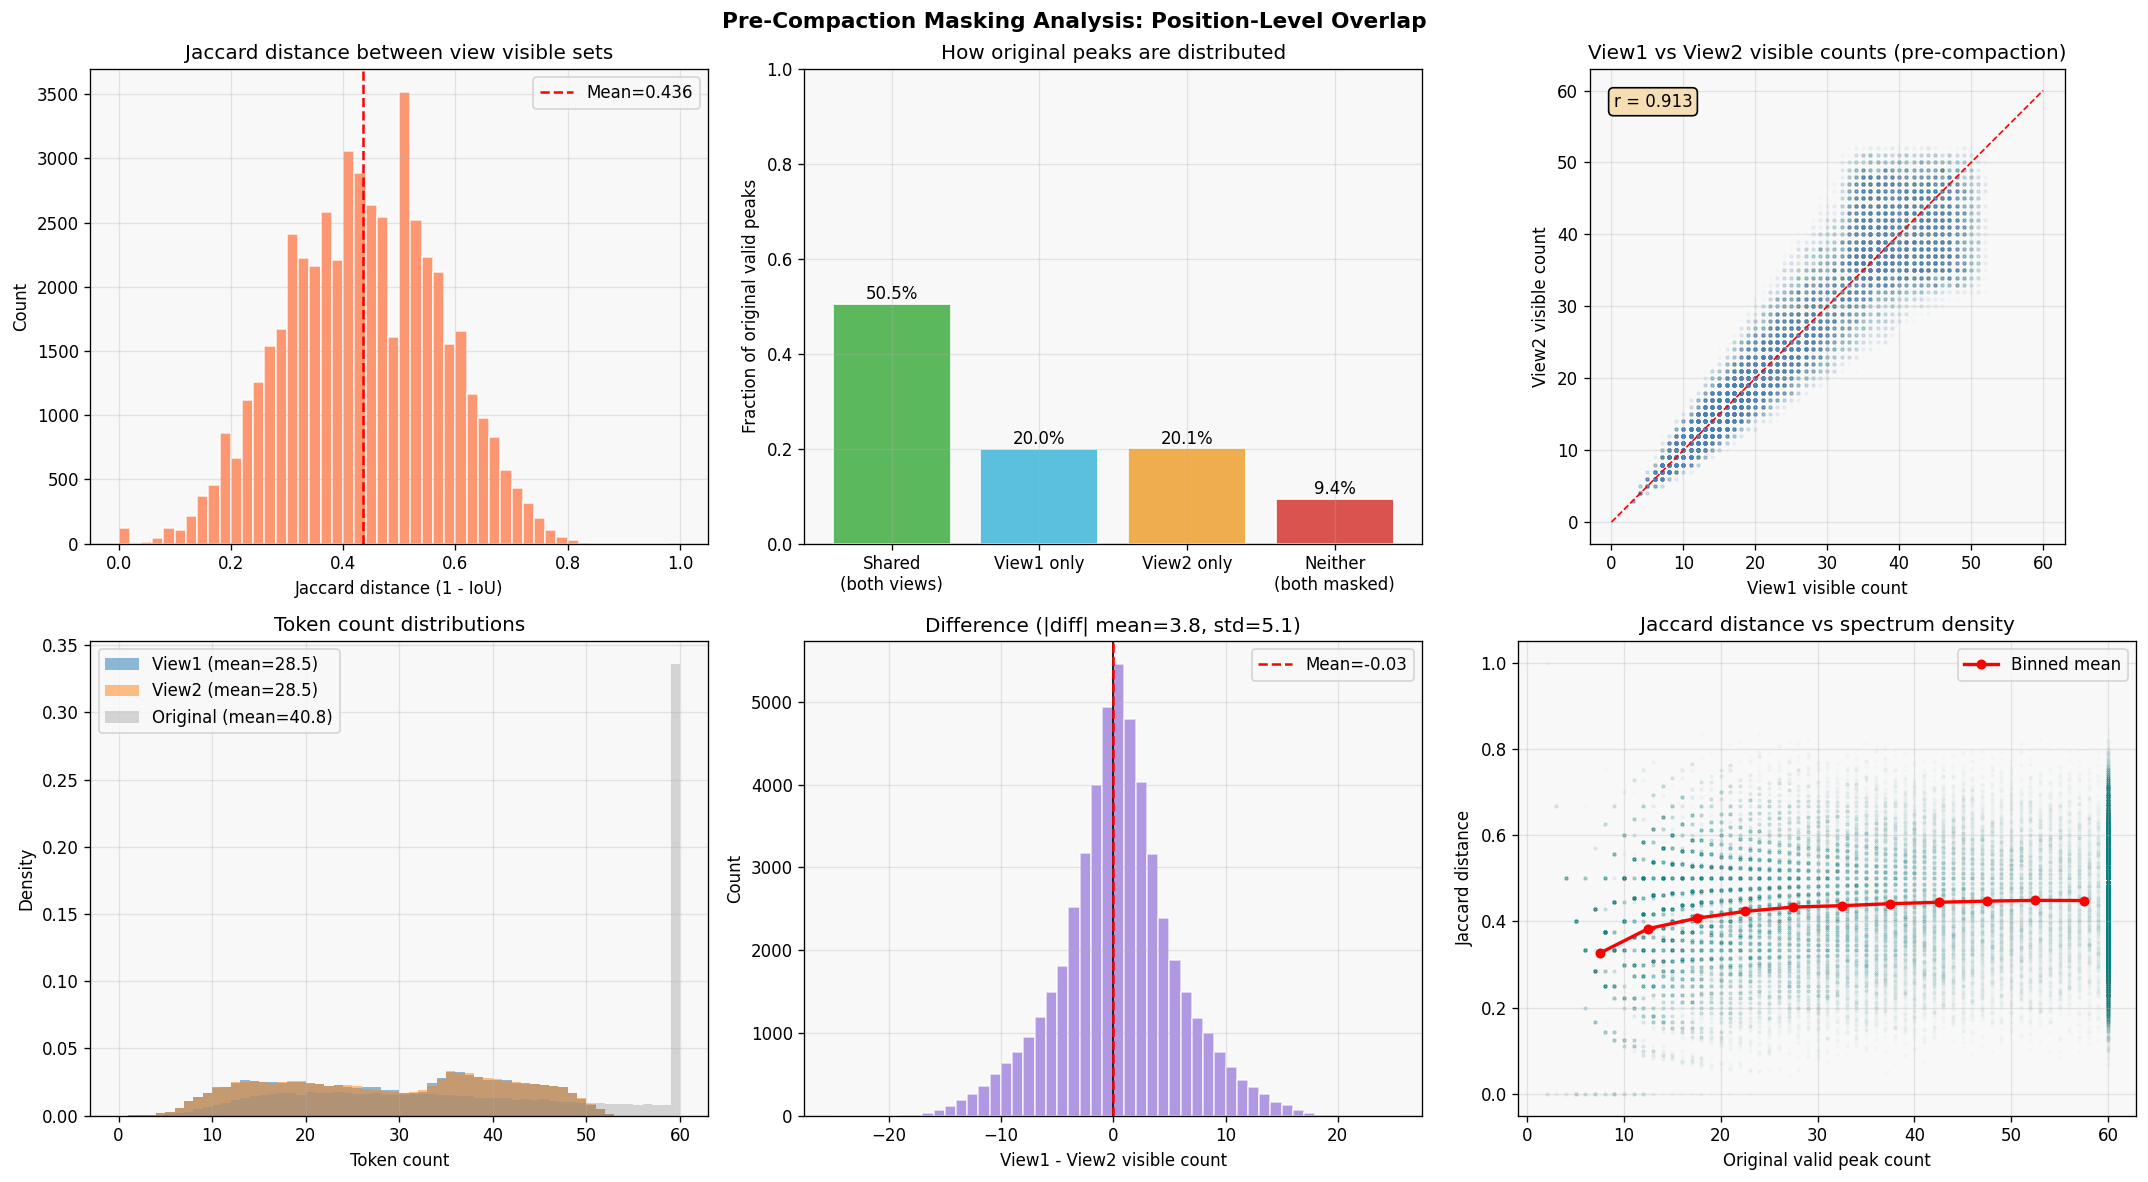

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Pre-Compaction Masking Analysis: Position-Level Overlap",
    fontsize=13,
    fontweight="bold",
)

# (a) Jaccard distance distribution
ax = axes[0, 0]
ax.hist(jaccard_dists, bins=50, color="coral", edgecolor="white", alpha=0.8)
ax.axvline(
    jaccard_dists.mean(), color="red", ls="--", label=f"Mean={jaccard_dists.mean():.3f}"
)
ax.set_xlabel("Jaccard distance (1 - IoU)")
ax.set_ylabel("Count")
ax.set_title("Jaccard distance between view visible sets")
ax.legend()

# (b) Shared vs exclusive fractions (stacked bar)
ax = axes[0, 1]
labels = ["Shared\n(both views)", "View1 only", "View2 only", "Neither\n(both masked)"]
neither_frac = 1 - shared_fracs.mean() - v1_only_fracs.mean() - v2_only_fracs.mean()
vals = [shared_fracs.mean(), v1_only_fracs.mean(), v2_only_fracs.mean(), neither_frac]
colors = ["#5cb85c", "#5bc0de", "#f0ad4e", "#d9534f"]
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
for bar, val in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.1%}",
        ha="center",
        fontsize=10,
    )
ax.set_ylabel("Fraction of original valid peaks")
ax.set_title("How original peaks are distributed")
ax.set_ylim(0, 1.0)

# (c) View1 vs View2 visible counts (pre-compaction)
ax = axes[0, 2]
ax.scatter(v1_vis_counts, v2_vis_counts, alpha=0.01, s=3, c="steelblue")
ax.plot([0, 60], [0, 60], "r--", lw=1)
ax.set_xlabel("View1 visible count")
ax.set_ylabel("View2 visible count")
ax.set_title("View1 vs View2 visible counts (pre-compaction)")
r = np.corrcoef(v1_vis_counts, v2_vis_counts)[0, 1]
ax.text(
    0.05,
    0.95,
    f"r = {r:.3f}",
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat"),
)
ax.set_aspect("equal")

# (d) Visible count distributions overlaid
ax = axes[1, 0]
bins = np.arange(0, 61)
ax.hist(
    v1_vis_counts,
    bins=bins,
    alpha=0.5,
    color="C0",
    label=f"View1 (mean={v1_vis_counts.mean():.1f})",
    density=True,
)
ax.hist(
    v2_vis_counts,
    bins=bins,
    alpha=0.5,
    color="C1",
    label=f"View2 (mean={v2_vis_counts.mean():.1f})",
    density=True,
)
ax.hist(
    orig_counts,
    bins=bins,
    alpha=0.3,
    color="gray",
    label=f"Original (mean={orig_counts.mean():.1f})",
    density=True,
)
ax.set_xlabel("Token count")
ax.set_ylabel("Density")
ax.set_title("Token count distributions")
ax.legend()

# (e) |diff| histogram
ax = axes[1, 1]
diff = v1_vis_counts.astype(int) - v2_vis_counts.astype(int)
ax.hist(
    diff, bins=np.arange(-25, 26), alpha=0.7, color="mediumpurple", edgecolor="white"
)
ax.axvline(0, color="black", ls="-", lw=1)
ax.axvline(diff.mean(), color="red", ls="--", label=f"Mean={diff.mean():.2f}")
ax.set_xlabel("View1 - View2 visible count")
ax.set_ylabel("Count")
ax.set_title(
    f"Difference (|diff| mean={np.abs(diff).mean():.1f}, std={diff.std():.1f})"
)
ax.legend()

# (f) Jaccard distance vs original valid count
ax = axes[1, 2]
ax.scatter(orig_counts, jaccard_dists, alpha=0.01, s=3, c="teal")
# Bin and plot mean
bins_c = np.arange(5, 61, 5)
bin_idx = np.digitize(orig_counts, bins_c)
bin_means = [jaccard_dists[bin_idx == i].mean() for i in range(1, len(bins_c))]
bin_centers = [(bins_c[i - 1] + bins_c[i]) / 2 for i in range(1, len(bins_c))]
ax.plot(bin_centers, bin_means, "ro-", lw=2, markersize=5, label="Binned mean")
ax.set_xlabel("Original valid peak count")
ax.set_ylabel("Jaccard distance")
ax.set_title("Jaccard distance vs spectrum density")
ax.legend()

plt.tight_layout()
plt.savefig("notebooks/fig_masking_overlap.png", bbox_inches="tight")
plt.show()

## 5. Effective Masking Fractions Per-Sample

What fraction of original peaks actually gets masked in each view?
And how does the effective total masking (neither view sees) compare?

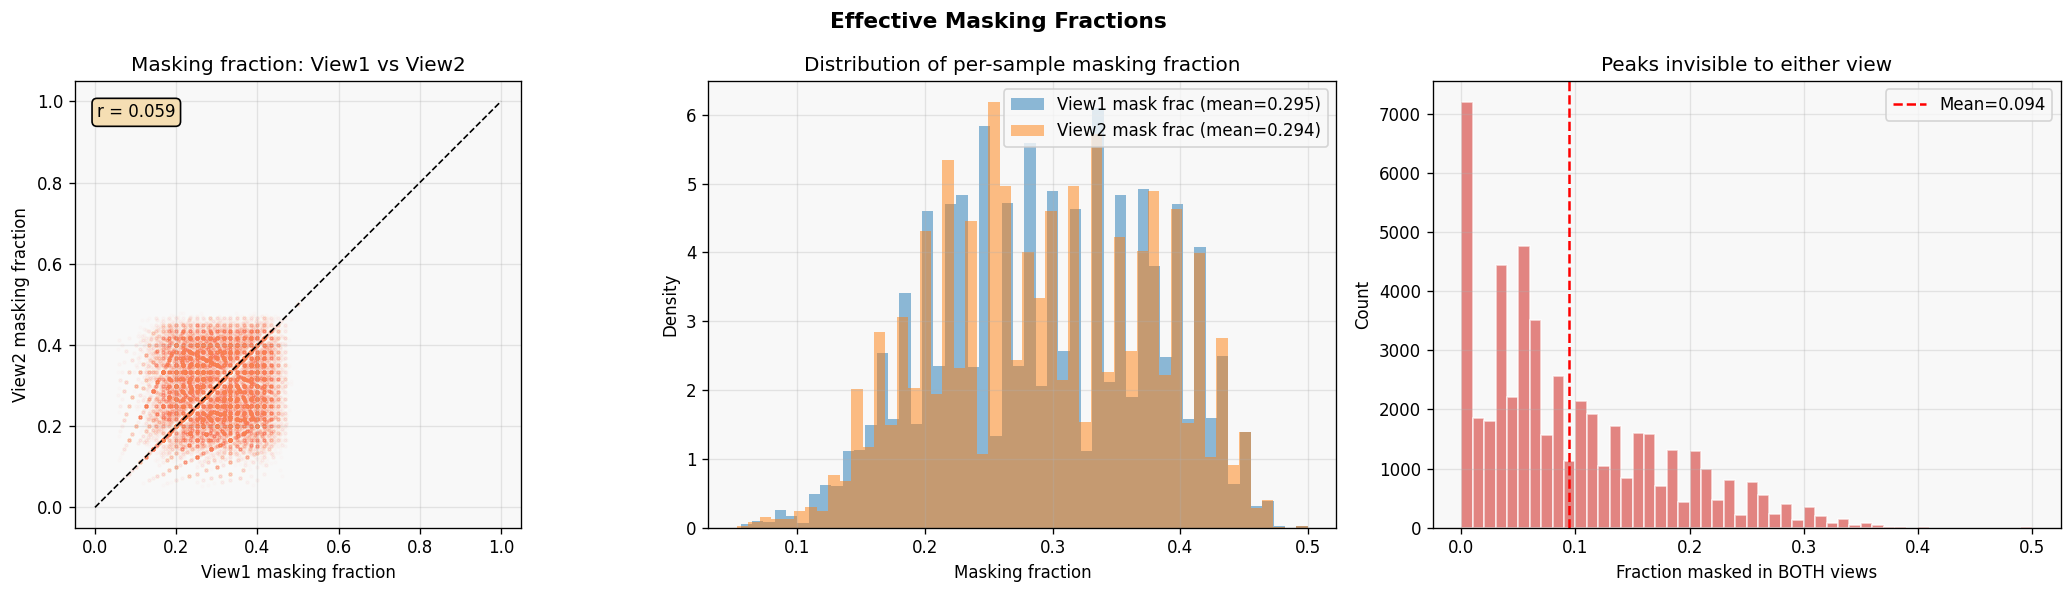


Mean masking fraction view1: 0.2947
Mean masking fraction view2: 0.2940
Mean fraction masked in BOTH views: 0.0940
Mean fraction visible in BOTH views: 0.5053


In [8]:
v1_mask_frac = 1 - v1_vis_counts / np.maximum(orig_counts, 1)
v2_mask_frac = 1 - v2_vis_counts / np.maximum(orig_counts, 1)
total_hidden_frac = 1 - shared_fracs - v1_only_fracs - v2_only_fracs  # masked in both

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Effective Masking Fractions", fontsize=13, fontweight="bold")

# (a) View1 vs View2 masking fraction
ax = axes[0]
ax.scatter(v1_mask_frac, v2_mask_frac, alpha=0.01, s=3, c="coral")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("View1 masking fraction")
ax.set_ylabel("View2 masking fraction")
ax.set_title("Masking fraction: View1 vs View2")
r = np.corrcoef(v1_mask_frac, v2_mask_frac)[0, 1]
ax.text(
    0.05,
    0.95,
    f"r = {r:.3f}",
    transform=ax.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat"),
)
ax.set_aspect("equal")

# (b) Distribution of masking fractions
ax = axes[1]
ax.hist(
    v1_mask_frac,
    bins=50,
    alpha=0.5,
    color="C0",
    label=f"View1 mask frac (mean={v1_mask_frac.mean():.3f})",
    density=True,
)
ax.hist(
    v2_mask_frac,
    bins=50,
    alpha=0.5,
    color="C1",
    label=f"View2 mask frac (mean={v2_mask_frac.mean():.3f})",
    density=True,
)
ax.set_xlabel("Masking fraction")
ax.set_ylabel("Density")
ax.set_title("Distribution of per-sample masking fraction")
ax.legend()

# (c) Fraction masked in BOTH views (totally invisible)
ax = axes[2]
ax.hist(total_hidden_frac, bins=50, alpha=0.7, color="#d9534f", edgecolor="white")
ax.axvline(
    total_hidden_frac.mean(),
    color="red",
    ls="--",
    label=f"Mean={total_hidden_frac.mean():.3f}",
)
ax.set_xlabel("Fraction masked in BOTH views")
ax.set_ylabel("Count")
ax.set_title("Peaks invisible to either view")
ax.legend()

plt.tight_layout()
plt.savefig("notebooks/fig_effective_masking.png", bbox_inches="tight")
plt.show()

print(f"\nMean masking fraction view1: {v1_mask_frac.mean():.4f}")
print(f"Mean masking fraction view2: {v2_mask_frac.mean():.4f}")
print(f"Mean fraction masked in BOTH views: {total_hidden_frac.mean():.4f}")
print(f"Mean fraction visible in BOTH views: {shared_fracs.mean():.4f}")

## 6. Per-Sample Venn Diagrams (Selected Samples)

Visualize how peaks are partitioned for individual spectra.

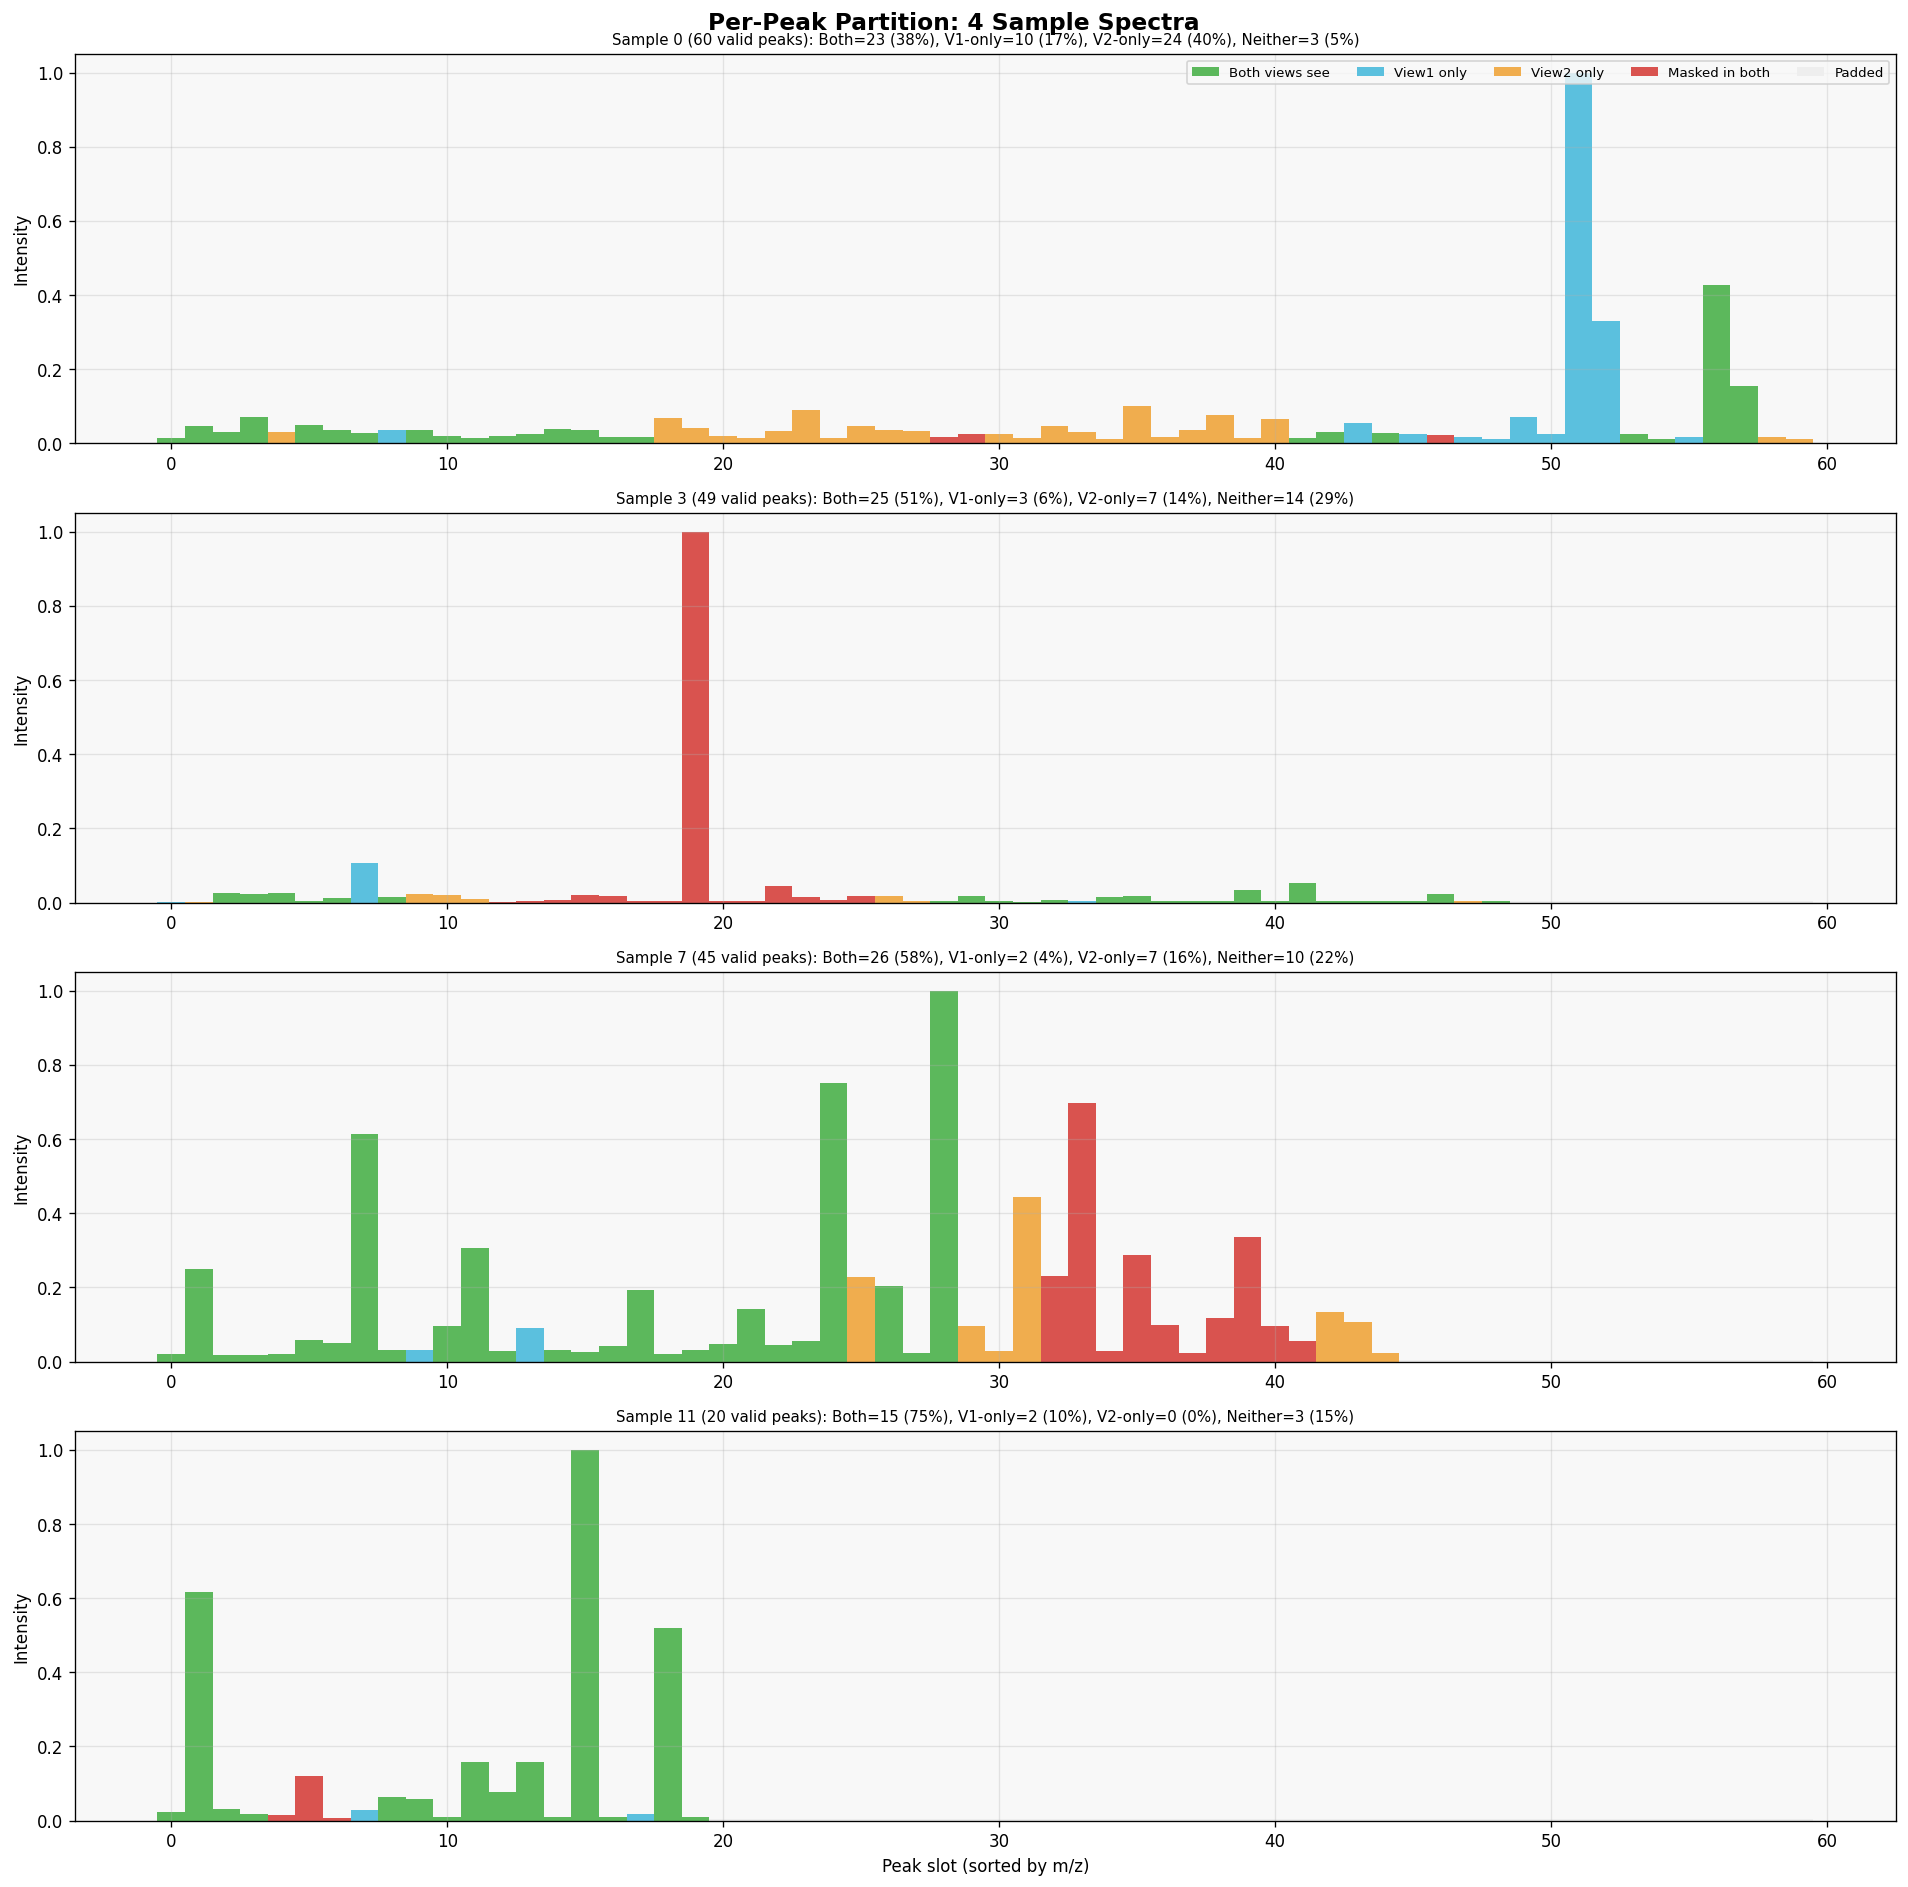

In [9]:
# Get a fresh batch with both raw and augmented data
raw_it2 = iter(raw_ds.as_numpy_iterator())
batch_raw = next(raw_it2)

peak_mz_tf = tf.constant(batch_raw["peak_mz"])
peak_valid_tf = tf.constant(batch_raw["peak_valid_mask"])

mask1, _ = _sample_contiguous_and_random_drop_mask_tf(
    peak_mz_tf,
    peak_valid_tf,
    contiguous_mask_fraction_min=cfg.sigreg_contiguous_mask_fraction_min,
    contiguous_mask_fraction_max=cfg.sigreg_contiguous_mask_fraction_max,
    random_drop_fraction_min=cfg.sigreg_random_drop_fraction_min,
    random_drop_fraction_max=cfg.sigreg_random_drop_fraction_max,
)
mask2, _ = _sample_contiguous_and_random_drop_mask_tf(
    peak_mz_tf,
    peak_valid_tf,
    contiguous_mask_fraction_min=cfg.sigreg_contiguous_mask_fraction_min,
    contiguous_mask_fraction_max=cfg.sigreg_contiguous_mask_fraction_max,
    random_drop_fraction_min=cfg.sigreg_random_drop_fraction_min,
    random_drop_fraction_max=cfg.sigreg_random_drop_fraction_max,
)

m1 = mask1.numpy()
m2 = mask2.numpy()
valid_np = batch_raw["peak_valid_mask"]
mz_np = batch_raw["peak_mz"]

fig, axes = plt.subplots(4, 1, figsize=(16, 16))
fig.suptitle("Per-Peak Partition: 4 Sample Spectra", fontsize=14, fontweight="bold")

for plot_i, sample_i in enumerate([0, 3, 7, 11]):
    ax = axes[plot_i]
    v = valid_np[sample_i]
    mk1 = m1[sample_i]
    mk2 = m2[sample_i]
    mz = mz_np[sample_i]

    vis1 = v & ~mk1
    vis2 = v & ~mk2

    # Categories:
    both_vis = vis1 & vis2  # visible in both
    only_v1 = vis1 & ~vis2  # only view1 sees
    only_v2 = ~vis1 & vis2  # only view2 sees
    neither = v & mk1 & mk2  # masked in both
    padded = ~v  # not valid

    n_peaks = len(mz)
    colors_bar = []
    for j in range(n_peaks):
        if padded[j]:
            colors_bar.append("#eeeeee")
        elif both_vis[j]:
            colors_bar.append("#5cb85c")  # green
        elif only_v1[j]:
            colors_bar.append("#5bc0de")  # blue
        elif only_v2[j]:
            colors_bar.append("#f0ad4e")  # orange
        elif neither[j]:
            colors_bar.append("#d9534f")  # red
        else:
            colors_bar.append("#999999")

    intensities = batch_raw["peak_intensity"][sample_i]
    heights = np.where(v, intensities, 0.005)  # small height for padded

    ax.bar(range(n_peaks), heights, color=colors_bar, width=1.0, edgecolor="none")

    n_both = both_vis.sum()
    n_v1 = only_v1.sum()
    n_v2 = only_v2.sum()
    n_neither = neither.sum()
    n_valid = v.sum()

    ax.set_title(
        f"Sample {sample_i} ({n_valid} valid peaks): "
        f"Both={n_both} ({n_both / max(n_valid, 1):.0%}), "
        f"V1-only={n_v1} ({n_v1 / max(n_valid, 1):.0%}), "
        f"V2-only={n_v2} ({n_v2 / max(n_valid, 1):.0%}), "
        f"Neither={n_neither} ({n_neither / max(n_valid, 1):.0%})",
        fontsize=9,
    )
    ax.set_ylabel("Intensity")
    if plot_i == 3:
        ax.set_xlabel("Peak slot (sorted by m/z)")

axes[0].legend(
    handles=[
        Patch(facecolor="#5cb85c", label="Both views see"),
        Patch(facecolor="#5bc0de", label="View1 only"),
        Patch(facecolor="#f0ad4e", label="View2 only"),
        Patch(facecolor="#d9534f", label="Masked in both"),
        Patch(facecolor="#eeeeee", label="Padded"),
    ],
    loc="upper right",
    fontsize=8,
    ncol=5,
)

plt.tight_layout()
plt.savefig("notebooks/fig_venn_samples.png", bbox_inches="tight")
plt.show()

## 7. Contiguous Mask Position Analysis

Where do the contiguous masks land? Do both views mask the same m/z region?

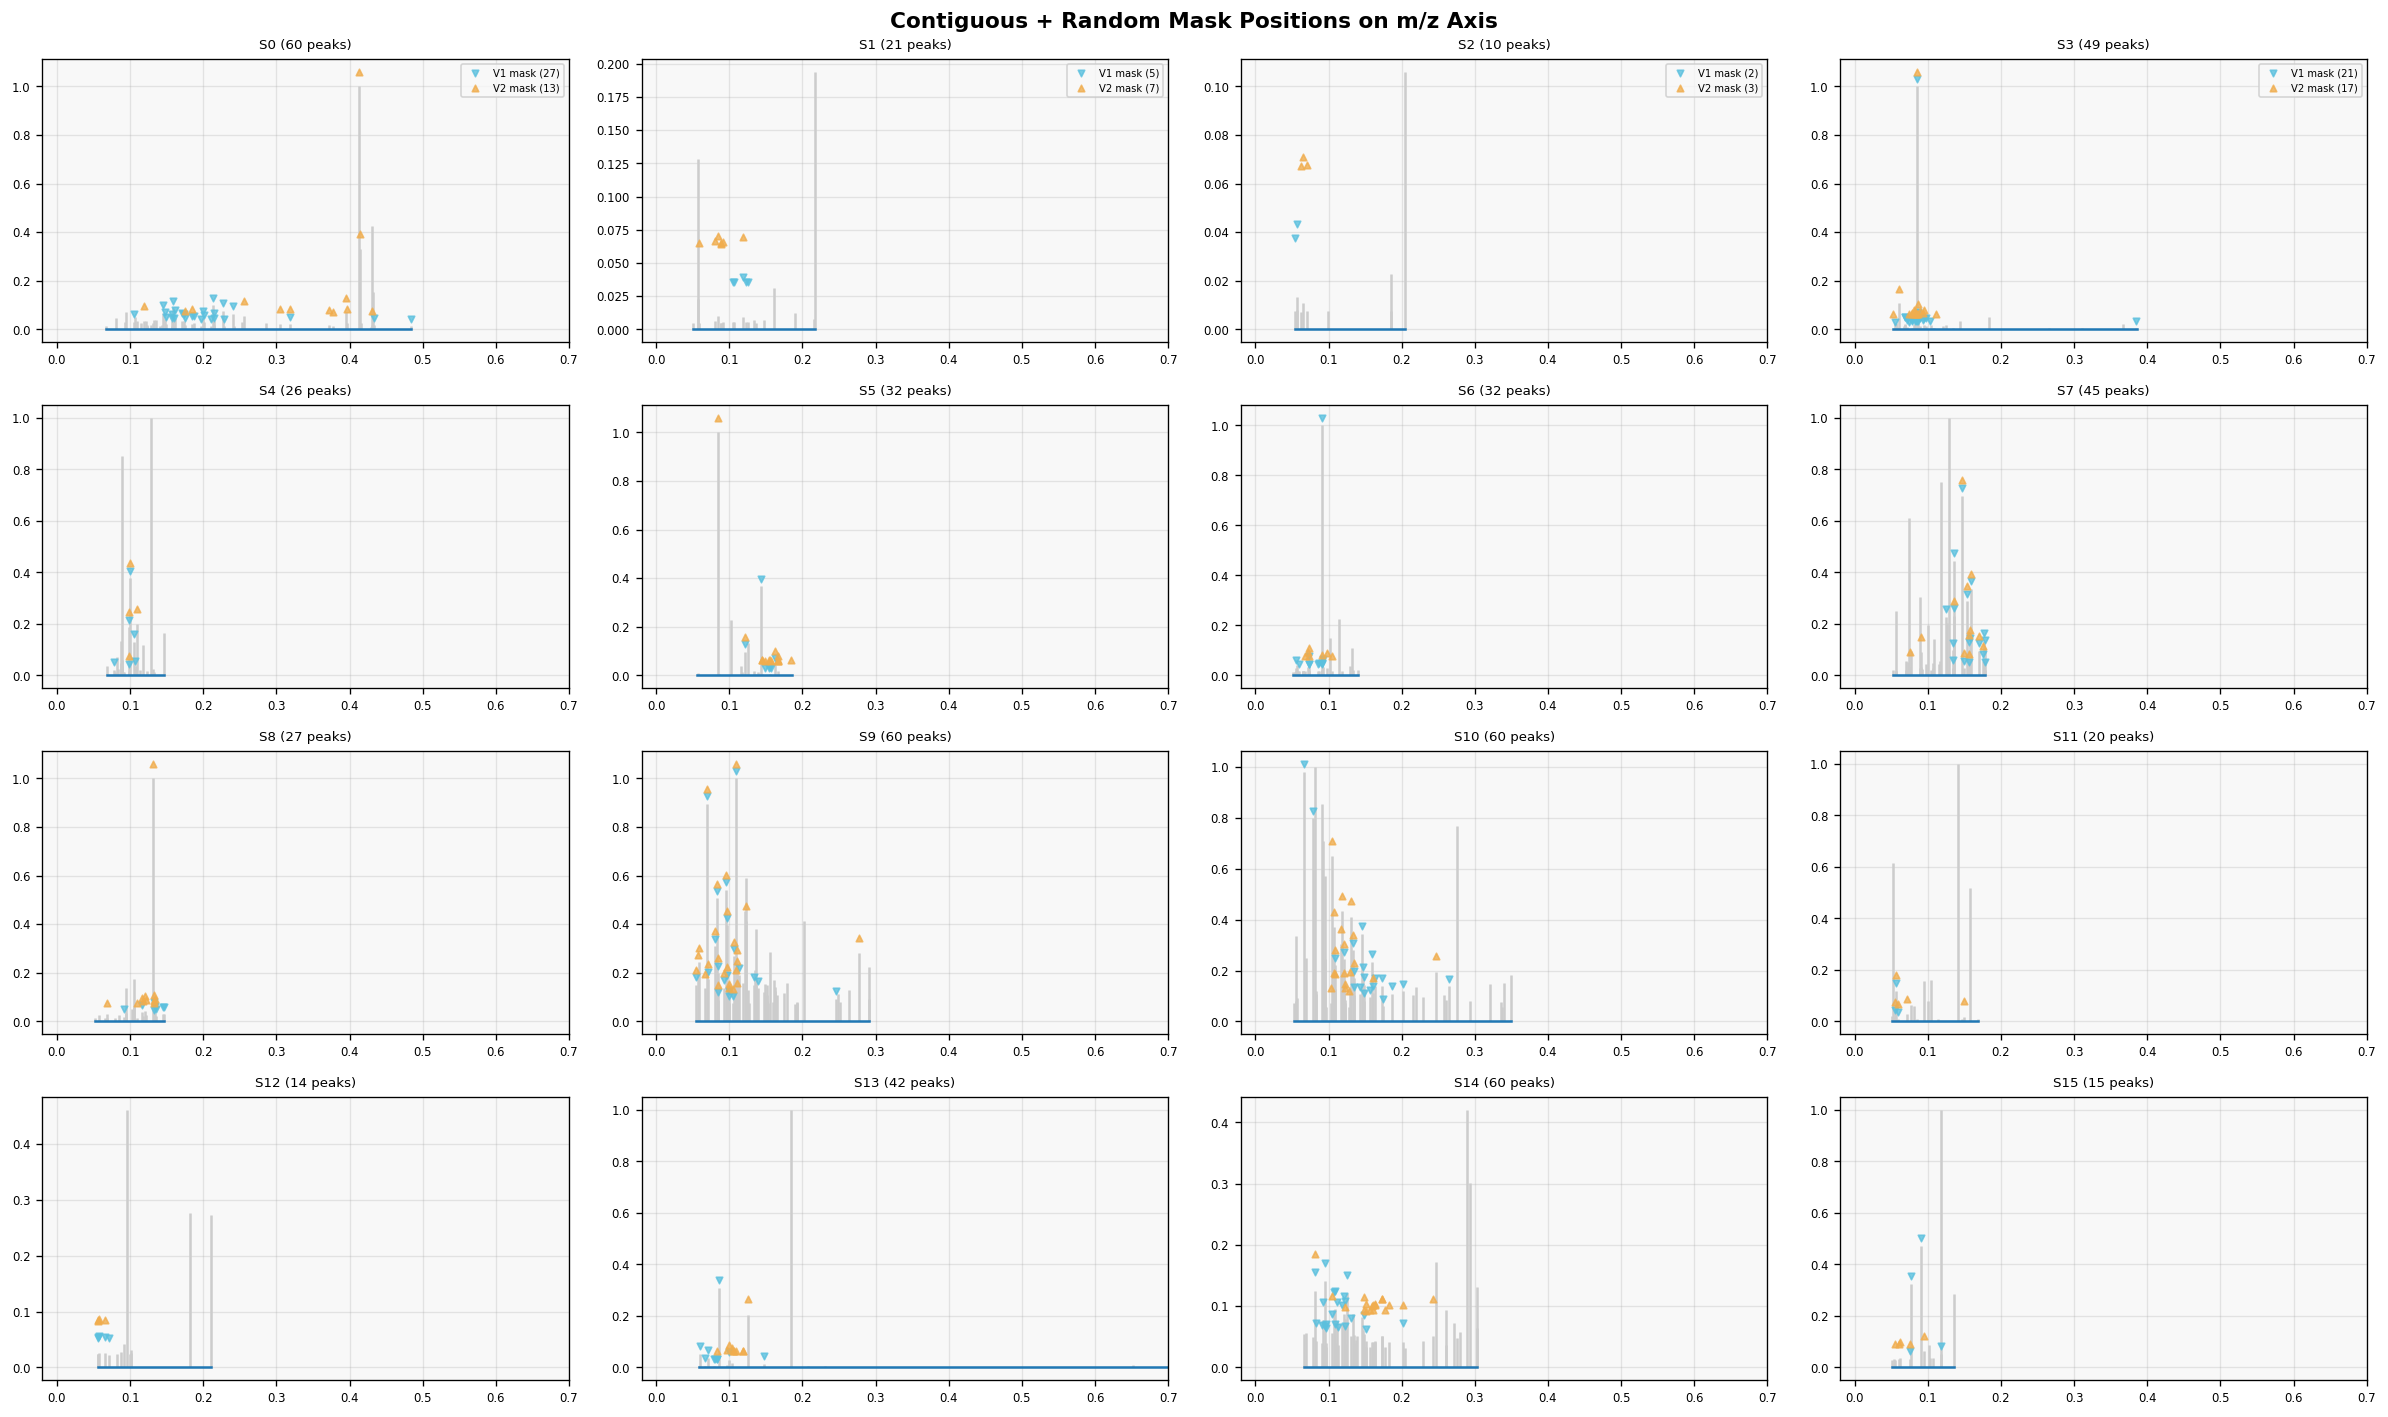

In [10]:
# For 16 samples, show the mask positions on the m/z axis
fig, axes = plt.subplots(4, 4, figsize=(20, 12))
fig.suptitle(
    "Contiguous + Random Mask Positions on m/z Axis", fontsize=13, fontweight="bold"
)

for idx, ax in enumerate(axes.flat):
    v = valid_np[idx]
    mk1 = m1[idx]
    mk2 = m2[idx]
    mz = mz_np[idx]
    inten = batch_raw["peak_intensity"][idx]

    vis1 = v & ~mk1
    vis2 = v & ~mk2

    # Plot original spectrum in gray
    valid_idx = np.where(v)[0]
    if len(valid_idx) > 0:
        ax.stem(
            mz[valid_idx],
            inten[valid_idx],
            linefmt="#cccccc",
            markerfmt="",
            basefmt="",
        )

    # Overlay view1 masked in blue, view2 masked in orange
    m1_idx = np.where(v & mk1)[0]
    m2_idx = np.where(v & mk2)[0]

    if len(m1_idx) > 0:
        ax.scatter(
            mz[m1_idx],
            inten[m1_idx] + 0.03,
            marker="v",
            s=15,
            c="#5bc0de",
            alpha=0.8,
            label=f"V1 mask ({len(m1_idx)})",
            zorder=5,
        )
    if len(m2_idx) > 0:
        ax.scatter(
            mz[m2_idx],
            inten[m2_idx] + 0.06,
            marker="^",
            s=15,
            c="#f0ad4e",
            alpha=0.8,
            label=f"V2 mask ({len(m2_idx)})",
            zorder=5,
        )

    ax.set_title(f"S{idx} ({v.sum()} peaks)", fontsize=8)
    ax.set_xlim(-0.02, 0.7)
    if idx < 4:
        ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("notebooks/fig_mask_positions.png", bbox_inches="tight")
plt.show()

## 8. Summary & Diagnosis

Key findings about why the two views have similar valid token counts.

In [11]:
print("=" * 70)
print("DIAGNOSIS: Why Two Views Have Similar Valid Token Counts")
print("=" * 70)
print()
print("ROOT CAUSE:")
print("  Both views independently sample masking parameters from the SAME")
print("  distribution. Since E[view1_mask_frac] = E[view2_mask_frac], the")
print("  expected visible count is identical for both views.")
print()
print("QUANTITATIVE EVIDENCE:")
print(
    f"  Original valid peaks:    {orig_counts.mean():.1f} +/- {orig_counts.std():.1f}"
)
print(
    f"  View1 visible:           {v1_vis_counts.mean():.1f} +/- {v1_vis_counts.std():.1f}"
)
print(
    f"  View2 visible:           {v2_vis_counts.mean():.1f} +/- {v2_vis_counts.std():.1f}"
)
print(
    f"  |View1 - View2| visible: {np.abs(v1_vis_counts - v2_vis_counts).mean():.1f} +/- {np.abs(v1_vis_counts - v2_vis_counts).std():.1f}"
)
print(f"  Jaccard distance:        {jaccard_dists.mean():.4f}")
print()
print("BREAKDOWN OF ORIGINAL PEAKS:")
print(f"  Visible in BOTH views:   {shared_fracs.mean():.1%}")
print(f"  View1 only:              {v1_only_fracs.mean():.1%}")
print(f"  View2 only:              {v2_only_fracs.mean():.1%}")
print(
    f"  Masked in BOTH:          {(1 - shared_fracs - v1_only_fracs - v2_only_fracs).mean():.1%}"
)
print()
print("IMPLICATIONS:")
print("  1. The views differ primarily in WHICH peaks they see (positions),")
print("     not in HOW MANY they see (counts).")
print("  2. The Jaccard distance tells us how much positional diversity exists.")
print(
    "  3. ~{:.0%} of peaks are seen by both views (high overlap).".format(
        shared_fracs.mean()
    )
)
print(
    "  4. Only ~{:.0%} of peaks are exclusive to one view.".format(
        v1_only_fracs.mean() + v2_only_fracs.mean()
    )
)
print()
print("COMPARISON TO ASYMMETRIC DESIGNS (e.g., I-JEPA):")
print("  In I-JEPA, the context encoder sees ~75-90% of patches while the")
print("  target encoder sees ~15-30%. This creates a clear asymmetry in")
print(
    "  information content. Here, both views see ~{:.0%} of peaks,".format(
        v1_vis_counts.mean() / orig_counts.mean()
    )
)
print("  making them nearly symmetric.")

DIAGNOSIS: Why Two Views Have Similar Valid Token Counts

ROOT CAUSE:
  Both views independently sample masking parameters from the SAME
  distribution. Since E[view1_mask_frac] = E[view2_mask_frac], the
  expected visible count is identical for both views.

QUANTITATIVE EVIDENCE:
  Original valid peaks:    40.8 +/- 17.5
  View1 visible:           28.5 +/- 12.3
  View2 visible:           28.5 +/- 12.3
  |View1 - View2| visible: 3.8 +/- 3.4
  Jaccard distance:        0.4357

BREAKDOWN OF ORIGINAL PEAKS:
  Visible in BOTH views:   50.5%
  View1 only:              20.0%
  View2 only:              20.1%
  Masked in BOTH:          9.4%

IMPLICATIONS:
  1. The views differ primarily in WHICH peaks they see (positions),
     not in HOW MANY they see (counts).
  2. The Jaccard distance tells us how much positional diversity exists.
  3. ~51% of peaks are seen by both views (high overlap).
  4. Only ~40% of peaks are exclusive to one view.

COMPARISON TO ASYMMETRIC DESIGNS (e.g., I-JEPA):
  In 